## Business Data Analysis 

In [34]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect("customer_churn.db")
subscription = pd.read_sql("SELECT * FROM db_subscription", conn)


customer_df = pd.read_sql("""
SELECT * FROM db_customer;
""", conn)

subscription = pd.read_sql(
    "SELECT * FROM db_subscription",
    conn
)

support = pd.read_sql(
    "SELECT * FROM db_support",
    conn
)

customer_df.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [35]:
customer_df.columns

Index(['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests',
       'pincode'],
      dtype='object')

In [51]:
unique_customers = customer_df['customerid'].nunique()
unique_customers

21

In [52]:
customer_df["dob"] = pd.to_datetime(customer_df["dob"])

customer_df["Age"] = (
    pd.Timestamp.today().year -
    customer_df["dob"].dt.year
)

def age_category(age):
    if age < 30:
        return "Young"
    elif age < 60:
        return "Adult"
    else:
        return "Senior"

customer_df["Age Category"] = customer_df["Age"].apply(age_category)
age_count = customer_df["Age Category"].value_counts()
age_count

Age Category
Adult    16
Young     5
Name: count, dtype: int64

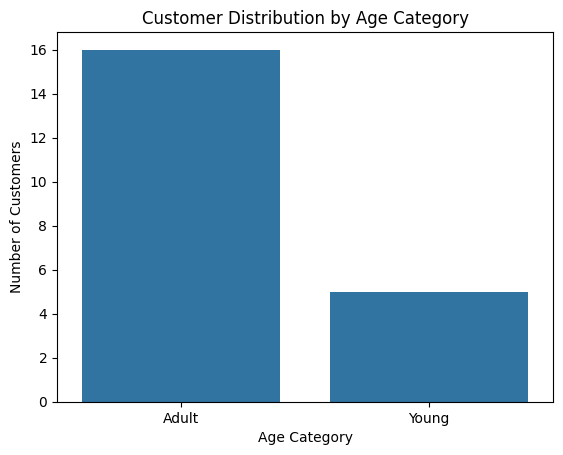

In [53]:
sns.barplot(
    x=age_count.index,
    y=age_count.values
)

plt.title("Customer Distribution by Age Category")
plt.xlabel("Age Category")
plt.ylabel("Number of Customers")

plt.show()

In [39]:
gender_count = customer_df['gender'].value_counts()
gender_count

gender
Female    9
Male      6
Women     3
Men       3
Name: count, dtype: int64

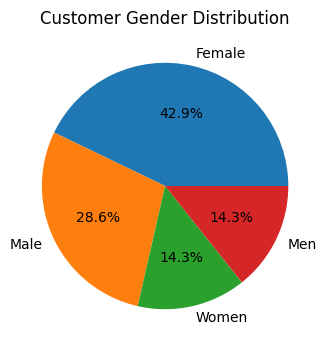

In [40]:
plt.figure(figsize=(4,4))
plt.pie(
    gender_count.values,
    labels=gender_count.index,
    autopct='%1.1f%%'
)
plt.title("Customer Gender Distribution")
plt.show()

In [41]:
merge = customer_df.merge(subscription,on="customerid")
merge.groupby("gender")["monthly_charges"].mean()

gender
Female    12.656667
Male      16.156667
Men       46.323333
Women     15.323333
Name: monthly_charges, dtype: float64

In [54]:
country = customer_df["country"].value_counts()
country

country
India    17
Nepal     1
Name: count, dtype: int64

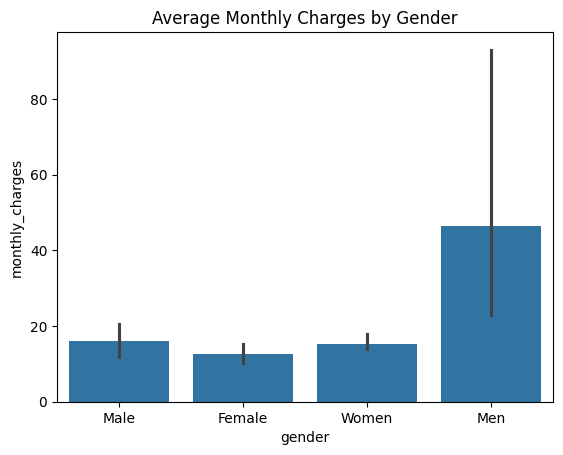

In [55]:
sns.barplot(
    data=merge,
    x="gender",
    y="monthly_charges"
)

plt.title("Average Monthly Charges by Gender")
plt.show()

In [56]:
country = customer_df["country"].value_counts()
country

country
India    17
Nepal     1
Name: count, dtype: int64

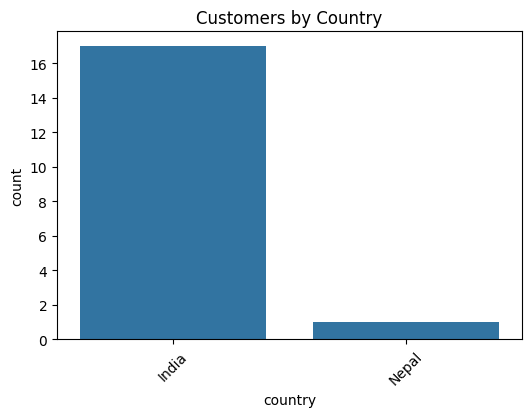

In [57]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=customer_df,
    x="country",
    order=country.index
)

plt.xticks(rotation=45)
plt.title("Customers by Country")
plt.show()

In [58]:
merged = customer_df.merge(support,on="customerid")
merged.groupby("country")["csat_score"].mean()

country
India    34.375
Name: csat_score, dtype: float64

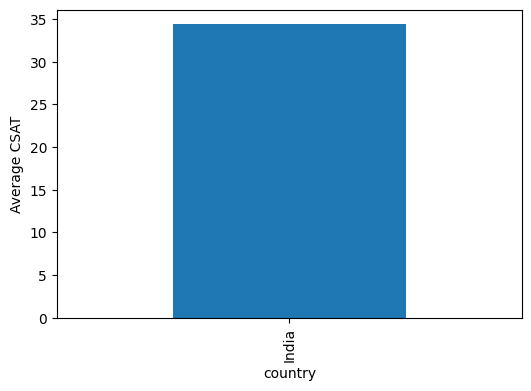

In [59]:
country_csat = merged.groupby("country")["csat_score"].mean()

country_csat.plot(kind="bar", figsize=(6,4))

plt.ylabel("Average CSAT")
plt.show()

In [60]:
merged.groupby("gender")["csat_score"].mean()

gender
Female    26.25
Male      42.50
Women     90.00
Name: csat_score, dtype: float64

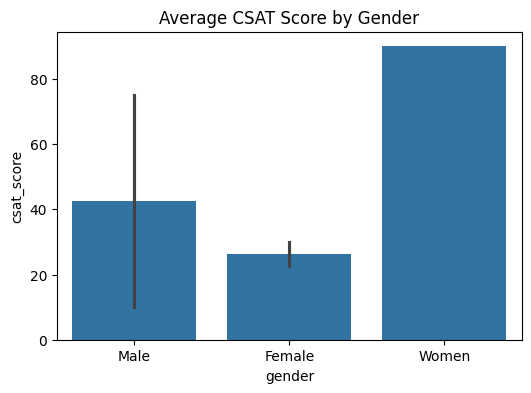

In [61]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=merged,
    x="gender",
    y="csat_score"
)

plt.title("Average CSAT Score by Gender")

plt.show()